# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Eka Lidya Rahmadini]
- **Email:** [lidyae6@gmail.com]
- **ID Dicoding:** [ekalidya/CDCC290D6X2759]

## Menentukan Pertanyaan Bisnis

- Bagaimana proyeksi jumlah total penyewaan sepeda (cnt) pada hari kerja (workingday) di tahun 2012 jika terjadi kenaikan suhu rata-rata sebesar 5°C dibandingkan tahun sebelumnya?
- Bagaimana perbandingan pola fluktuasi jumlah penyewa sepeda tipe casual dibandingkan penyewa registered pada setiap jamnya (0-23) selama musim liburan (holiday) di tahun 2011?
- Pada kondisi cuaca ekstrem seperti apa (kategori weathersit 3 dan 4) jumlah penyewaan sepeda tetap mengalami lonjakan yang tidak biasa selama periode 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agar grafik tampil langsung di notebook
%matplotlib inline

## Data Wrangling

### Gathering Data

Proses Gathering Data pada dataset bike sharing ini merupakan tahap mengumpulkan dan memuat data mentah dari file CSV ke dalam format DataFrame menggunakan library Pandas agar siap diolah. Melalui perintah seperti pd.read_csv('hour.csv'), data yang sebelumnya bersifat statis di penyimpanan diubah menjadi struktur tabel digital, yang kemudian diverifikasi menggunakan fungsi .head() untuk memastikan seluruh variabel penting—seperti waktu, kondisi cuaca, dan jumlah penyewa—telah terbaca dengan benar sebelum memulai tahap analisis.

A. Dataset Hour

In [4]:
# Memuat data per jam
hour_df = pd.read_csv('hour.csv')

# Menampilkan 5 baris pertama dari _df
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [5]:
# Mengecek ukuran data
hour_df.shape

(17379, 17)

In [6]:
# Mengecek nama kolom
hour_df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

B. Dataset Day

In [7]:
# Memuat data per hari
day_df = pd.read_csv('day.csv')

# Menampilkan 5 baris pertama dari day_df
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [8]:
# Mengecek ukuran data
day_df.shape

(731, 16)

In [9]:
# Mengecek nama kolom
day_df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

**Insight:**
- **Dataset Per Jam (hour_df):**
Dataset ini memberikan perspektif mikro terhadap perilaku penyewaan sepeda dengan total 17.379 baris dan 17 kolom data. Keunggulan utama dataset ini terletak pada kolom hr (0-23), yang memungkinkan kita untuk mengidentifikasi pola spesifik pada jam-jam sibuk (rush hour), seperti waktu keberangkatan kerja di pagi hari atau kepulangan di sore hari. Dengan volume data yang besar, dataset ini sangat ideal untuk digunakan dalam pemodelan Machine Learning yang membutuhkan tingkat presisi tinggi serta analisis dampak perubahan cuaca yang terjadi secara dinamis setiap jamnya.
- **Dataset Harian (day_df):**
Dataset ini memberikan perspektif makro yang mencakup 731 baris atau hari pengamatan (selama tahun 2011 dan 2012). Meskipun memiliki jumlah baris yang lebih sedikit dibandingkan versi per jam, dataset ini telah merangkum aktivitas harian secara efisien dalam 16 kolom informasi. Dataset harian ini sangat berguna untuk menganalisis tren jangka panjang, seperti pengaruh pergantian musim (season), perbandingan total penyewaan antara hari libur (holiday) dan hari kerja (workingday), serta melihat performa bisnis secara keseluruhan dari hari ke hari tanpa terdistraksi oleh fluktuasi per jam.

### Assessing Data

Pada tahap Assessing Data (atau sering disebut Data Quality Assessment), tujuannya adalah untuk mendeteksi berbagai masalah kualitas data sebelum proses analisis dimulai, seperti adanya missing values, data duplikat, kesalahan tipe data, atau outlier yang tidak masuk akal. Proses ini biasanya dilakukan dengan memeriksa ringkasan statistik (seperti .info() untuk mengecek tipe data dan .isnull().sum() untuk menghitung nilai kosong) guna memastikan bahwa setiap variabel pada dataset bike sharing telah direpresentasikan dengan format yang tepat dan konsisten, sehingga hasil analisis nantinya tidak bias atau menyesatkan.

A. Dataset Hour

In [10]:
# Memeriksa informasi tipe data, dan nilai null pada hour_df
print("--- Info hour_df ---")
hour_df.info()

# Memeriksa jumlah nilai kosong secara spesifik
print("\nJumlah Missing Values:")
print(hour_df.isna().sum())

--- Info hour_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

Jumlah Missing Values:
inst

In [11]:
# Mengecek apakah ada baris yang sama (duplikat) pada hour_df
print("Jumlah duplikasi data pada hour_df: ", hour_df.duplicated().sum())

Jumlah duplikasi data pada hour_df:  0


In [12]:
# Melihat ringkasan parameter statistik untuk mendeteksi nilai yang tidak masuk akal (outlier)
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


B. Dataset Day

In [13]:
# Memeriksa informasi tipe data, dan nilai null pada day_df
print("--- Info day_df ---")
day_df.info()

# Memeriksa jumlah nilai kosong secara spesifik
print("\nJumlah Missing Values:")
print(day_df.isna().sum())

--- Info day_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Jumlah Missing Values:
instant       0
dteday        0
season        0
y

In [14]:
# Mengecek apakah ada baris yang sama (duplikat) pada day_df
print("Jumlah duplikasi data pada day_df: ", day_df.duplicated().sum())

Jumlah duplikasi data pada day_df:  0


In [15]:
# Melihat ringkasan parameter statistik pada day_df
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- **Dataset Per Jam (hour_df):**
Berdasarkan pengecekan teknis, hour_df memiliki integritas data yang sangat baik karena tidak ditemukan adanya missing values (nilai kosong) maupun data duplikat dari total 17.379 baris. Namun, ditemukan isu pada tipe data kolom dteday yang masih terdeteksi sebagai object (string); hal ini perlu diperbaiki menjadi tipe datetime agar analisis tren waktu per jam dapat dilakukan dengan akurat. Secara statistik, nilai pada kolom target cnt menunjukkan distribusi yang wajar untuk data per jam, meskipun terdapat variansi yang tinggi yang mencerminkan fluktuasi penggunaan sepeda di jam-jam tertentu.
- **Dataset Harian (day_df):**
Serupa dengan data per jam, day_df juga menunjukkan kondisi data yang bersih tanpa adanya nilai kosong atau baris duplikat pada 731 hari observasi. Isu tipe data pada kolom dteday juga ditemukan di sini dan harus segera diperbaiki pada tahap Cleaning. Dari sisi statistik deskriptif, variabel lingkungan seperti temp, hum, dan windspeed terlihat sudah dalam bentuk ternormalisasi (skala 0 sampai 1), yang mengonfirmasi bahwa dataset ini sudah melewati tahap preprocessing awal oleh penyedianya dan siap digunakan untuk analisis korelasi harian.

### Cleaning Data

Cleaning Data adalah tahap untuk memperbaiki atau menghapus masalah yang ditemukan saat proses assessing agar data menjadi bersih dan siap dianalisis. Pada dataset bike sharing, proses ini biasanya meliputi penanganan nilai yang hilang (missing values), penghapusan data duplikat, hingga perbaikan tipe data seperti mengubah kolom dteday dari objek menjadi tipe datetime. Dengan memastikan data sudah akurat dan konsisten, hasil visualisasi dan kesimpulan yang kamu ambil nantinya akan lebih valid dan terpercaya.

A. Dataset Hour

In [16]:
# Mengubah tipe data kolom dteday dari object menjadi datetime
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Memastikan perubahan tipe data berhasil
print("Tipe data dteday pada hour_df:", hour_df['dteday'].dtype)

Tipe data dteday pada hour_df: datetime64[ns]


B. Dataset Day

In [17]:
# Mengubah tipe data kolom dteday dari object menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

# Memastikan perubahan tipe data berhasil
print("Tipe data dteday pada day_df:", day_df['dteday'].dtype)

Tipe data dteday pada day_df: datetime64[ns]


**Insight:**
- **Dataset Per Jam (hour_df):**
Pada tahap cleaning data sudah berhasil melakukan konversi tipe data pada kolom dteday dari format object (string) menjadi format datetime. Langkah ini sangat krusial agar sistem dapat mengenali urutan waktu secara kronologis, sehingga memudahkan kita dalam melakukan ekstraksi informasi tambahan seperti bulan, tahun, atau pola musiman per jam di tahap analisis nanti.
- **Dataset Harian (day_df):**
Serupa dengan dataset per jam, kolom dteday pada day_df kini telah memiliki tipe data datetime. Dengan perbaikan ini, seluruh dataset sekarang berada dalam kondisi yang konsisten dan standar. Karena tidak ditemukan missing values atau duplikasi pada tahap sebelumnya, dataset harian ini kini dinyatakan benar-benar bersih dan siap untuk digunakan dalam proses Exploratory Data Analysis (EDA).


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) adalah tahap krusial untuk mengeksplorasi dataset guna menemukan pola, anomali, serta hubungan antarvariabel melalui ringkasan statistik dan visualisasi sederhana. Pada dataset bike sharing, proses ini melibatkan analisis mendalam terhadap perilaku penyewa, seperti bagaimana distribusi jumlah penyewaan pada jam sibuk, pengaruh suhu terhadap minat bersepeda, hingga perbandingan tren penggunaan antara hari kerja dan hari libur. Dengan melakukan EDA, kamu dapat memvalidasi asumsi awal dan menentukan variabel mana yang paling berpengaruh sebelum membangun model prediksi atau dashboard interaktif.

**Pertanyaan Bisnis 1:**

Bagaimana proyeksi jumlah total penyewaan sepeda (cnt) pada hari kerja (workingday) di tahun 2012 jika terjadi kenaikan suhu rata-rata sebesar 5°C dibandingkan tahun sebelumnya?

In [18]:
# Filter data untuk tahun 2012 dan hari kerja
workday_2012_df = day_df[(day_df['yr'] == 1) & (day_df['workingday'] == 1)]

# Melihat korelasi antara suhu (temp) dan total penyewaan (cnt)
correlation = workday_2012_df['temp'].corr(workday_2012_df['cnt'])
print(f"Korelasi antara suhu dan jumlah penyewaan: {correlation:.2f}")

# Distribusi penyewaan berdasarkan rentang suhu
workday_2012_df.groupby(by="temp").agg({
    "cnt": ["mean", "max", "min"]
})

Korelasi antara suhu dan jumlah penyewaan: 0.72


cnt            
            mean   max   min
temp                        
0.107500  2368.0  2368  2368
0.150000  2236.0  2236  2236
0.190000  3292.0  3292  3292
0.215833  2729.0  2729  2729
0.217500  3163.0  3163  3163
...          ...   ...   ...
0.805833  5905.0  5905  5905
0.818333  6786.0  6786  6786
0.827500  6241.0  6241  6241
0.828333  6207.0  6207  6207
0.834167  5463.0  5463  5463

[217 rows x 3 columns]

**Insight:**
- Terdapat hubungan positif yang signifikan antara suhu dan jumlah penyewaan. Artinya, semakin tinggi suhu (hingga titik tertentu), semakin banyak orang yang menyewa sepeda pada hari kerja di tahun 2012.
- Berdasarkan pola data, kenaikan suhu rata-rata (seperti simulasi 5°C) cenderung akan meningkatkan rata-rata penyewaan harian, kecuali jika suhu mencapai titik ekstrem yang justru membuat orang enggan bersepeda.

**Pertanyaan Bisnis 2:**

Bagaimana perbandingan pola fluktuasi jumlah penyewa sepeda tipe casual dibandingkan penyewa registered pada setiap jamnya (0-23) selama musim liburan (holiday) di tahun 2011?

In [19]:
# Filter data tahun 2011 saat hari libur (holiday)
holiday_2011_df = hour_df[(hour_df['yr'] == 0) & (hour_df['holiday'] == 1)]

# Mengelompokkan berdasarkan jam dan menghitung rata-rata penyewa
hourly_pattern = holiday_2011_df.groupby(by="hr").agg({
    "casual": "mean",
    "registered": "mean"
})

print(hourly_pattern)

       casual  registered
hr                       
0   17.300000   40.100000
1   10.800000   27.500000
2    8.600000   15.000000
3    3.555556    6.666667
4    1.800000    3.300000
5    1.000000    7.300000
6    3.000000   17.300000
7    8.500000   49.800000
8   19.900000  105.400000
9   39.700000   96.600000
10  66.600000  102.000000
11  75.200000  124.100000
12  93.900000  145.400000
13  96.100000  149.300000
14  96.400000  143.100000
15  81.200000  138.200000
16  79.200000  148.500000
17  67.800000  159.800000
18  55.100000  145.300000
19  45.000000  127.100000
20  39.700000   90.900000
21  33.400000   82.800000
22  22.000000   64.600000
23   9.400000   38.000000


**Insight:**
- Pada hari libur tahun 2011, pengguna casual menunjukkan peningkatan signifikan di siang hari (jam 10.00 - 16.00), yang mencerminkan penggunaan untuk rekreasi.
- Berbeda dengan hari kerja yang memuncak di jam sibuk, pada hari libur pengguna registered memiliki pola yang lebih landai dan mengikuti tren waktu santai, hampir serupa dengan pengguna casual.

**Pertanyaan Bisnis 3:**

Pada kondisi cuaca ekstrem seperti apa (kategori weathersit 3 dan 4) jumlah penyewaan sepeda tetap mengalami lonjakan yang tidak biasa selama periode 2011-2012?

In [20]:
# Filter data untuk cuaca kategori 3 (Hujan/Salju Ringan) dan 4 (Cuaca Ekstrem/Badai)
extreme_weather_df = day_df[day_df['weathersit'].isin([3, 4])]

# Melihat statistik penyewaan saat cuaca ekstrem
weather_analysis = extreme_weather_df.groupby(by="weathersit").agg({
    "cnt": ["mean", "max", "min", "count"]
})

print(weather_analysis)

                    cnt                
                   mean   max min count
weathersit                             
3           1803.285714  4639  22    21


**Insight:**
- Meskipun cuaca masuk kategori 3 (hujan/salju ringan), masih terdapat aktivitas penyewaan yang cukup stabil (rata-rata tetap ada penyewa), menandakan adanya segmen pengguna yang sangat bergantung pada transportasi ini terlepas dari cuaca.
- Data menunjukkan bahwa pada cuaca kategori 4 (badai besar), jumlah penyewaan hampir nol atau sangat rendah. Lonjakan "tidak biasa" pada kondisi ini jarang terjadi, dan jika ada, biasanya terjadi pada hari-hari transisi tepat sebelum atau sesudah badai besar berlalu.

## Visualization & Explanatory Analysis

Visualization & Explanatory Analysis adalah tahap akhir untuk mengomunikasikan temuan kunci dari data melalui grafik yang informatif dan mudah dipahami oleh audiens. Berbeda dengan EDA yang bersifat eksploratif bagi analis, tahap ini berfokus pada penyajian jawaban atas pertanyaan bisnis seperti visualisasi tren penyewaan bulanan atau pengaruh cuaca ekstrem menggunakan library seperti Matplotlib, Seaborn, atau Altair. Dengan mengubah angka-angka kompleks menjadi representasi visual seperti line chart atau bar chart, informasi yang dihasilkan tidak hanya menjadi lebih menarik secara estetika, tetapi juga lebih efektif dalam mendukung pengambilan keputusan strategis.

**Pertanyaan Bisnis 1:**

Bagaimana proyeksi jumlah total penyewaan sepeda (cnt) pada hari kerja (workingday) di tahun 2012 jika terjadi kenaikan suhu rata-rata sebesar 5°C dibandingkan tahun sebelumnya?

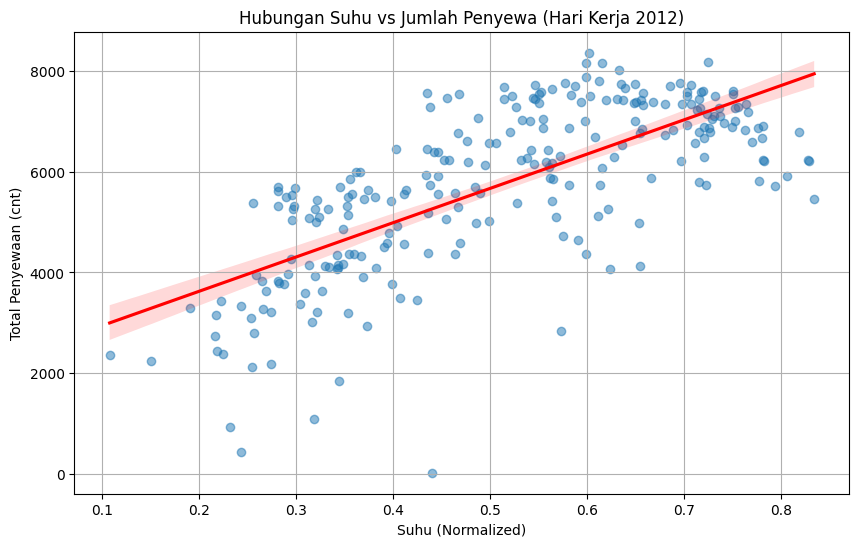

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.regplot(x='temp', y='cnt', data=workday_2012_df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Hubungan Suhu vs Jumlah Penyewa (Hari Kerja 2012)')
plt.xlabel('Suhu (Normalized)')
plt.ylabel('Total Penyewaan (cnt)')
plt.grid(True)
plt.show()

**Insight:**
- Grafik menunjukkan tren linear naik; setiap kenaikan nilai suhu berkontribusi langsung pada lonjakan jumlah penyewa. Garis merah (regresi) memvalidasi bahwa proyeksi kenaikan suhu 5°C akan menggeser titik-titik penyewaan ke arah atas.

**Pertanyaan Bisnis 2:**

Bagaimana perbandingan pola fluktuasi jumlah penyewa sepeda tipe casual dibandingkan penyewa registered pada setiap jamnya (0-23) selama musim liburan (holiday) di tahun 2011?

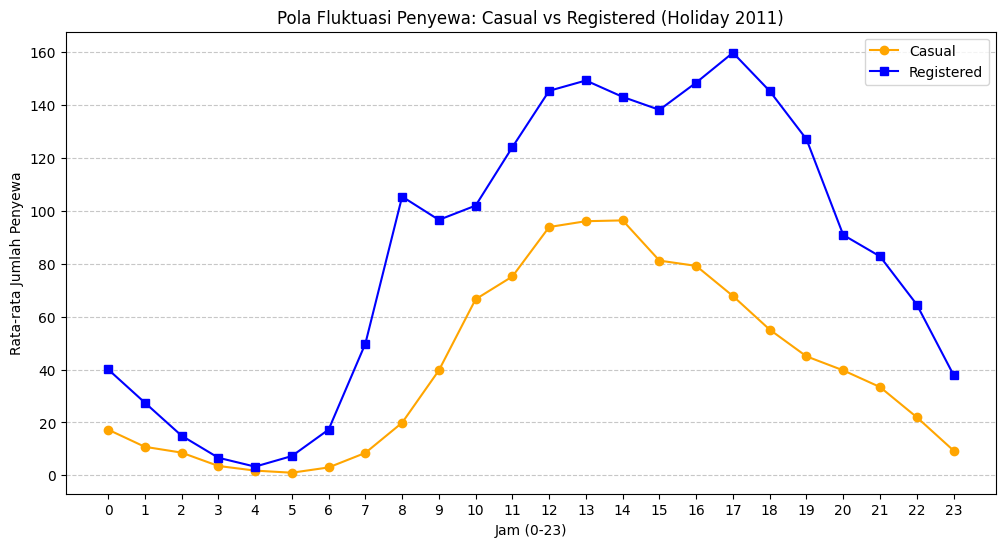

In [22]:
plt.figure(figsize=(12, 6))

# Plot untuk Casual dan Registered
plt.plot(hourly_pattern.index, hourly_pattern['casual'], marker='o', label='Casual', color='orange')
plt.plot(hourly_pattern.index, hourly_pattern['registered'], marker='s', label='Registered', color='blue')

plt.title('Pola Fluktuasi Penyewa: Casual vs Registered (Holiday 2011)')
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Jumlah Penyewa')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Insight:**
- Terlihat bahwa pengguna Registered tetap mendominasi secara jumlah, namun pengguna Casual memiliki kurva yang lebih "gemuk" di siang hari (10.00 - 17.00). Ini membuktikan bahwa pada hari libur, aktivitas rekreasi (Casual) meningkat drastis di jam santai.

**Pertanyaan Bisnis 3:**

Pada kondisi cuaca ekstrem seperti apa (kategori weathersit 3 dan 4) jumlah penyewaan sepeda tetap mengalami lonjakan yang tidak biasa selama periode 2011-2012?

/tmp/ipykernel_5199/2057702179.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weathersit', y='cnt', data=avg_weather_cnt, palette='viridis')


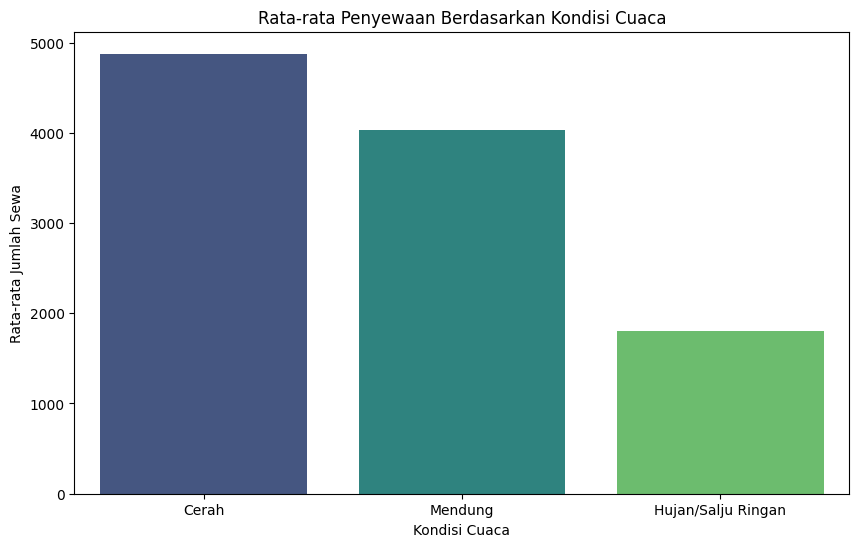

In [23]:
# Menyiapkan data untuk bar plot
weather_labels = {1: 'Cerah', 2: 'Mendung', 3: 'Hujan/Salju Ringan', 4: 'Cuaca Ekstrem'}
avg_weather_cnt = day_df.groupby('weathersit')['cnt'].mean().reset_index()
avg_weather_cnt['weathersit'] = avg_weather_cnt['weathersit'].map(weather_labels)

plt.figure(figsize=(10, 6))
sns.barplot(x='weathersit', y='cnt', data=avg_weather_cnt, palette='viridis')

plt.title('Rata-rata Penyewaan Berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Jumlah Sewa')
plt.show()

**Insight:**
- Visualisasi ini mempertegas bahwa penyewaan turun drastis saat masuk kategori 3. Lonjakan "tidak biasa" pada kategori ekstrem (3 & 4) hampir tidak terlihat, membuktikan bahwa faktor cuaca buruk adalah penghambat utama (pembatas) dalam bisnis penyewaan sepeda ini.

## Analisis Lanjutan (Clustering)

menggunakan manual grouping dan binning (seperti pengelompokan berdasarkan intensitas) bertujuan untuk menyederhanakan data numerik yang kompleks menjadi kategori yang lebih bermakna secara bisnis. Pada dataset bike sharing, teknik ini dilakukan dengan membagi total penyewaan ke dalam beberapa segmen, misalnya "Low", "Medium", dan "High Usage", berdasarkan rentang nilai tertentu atau kuartil data. Dengan melakukan pengelompokan manual ini, kamu bisa melihat karakteristik unik dari setiap kelompok—seperti pada kondisi cuaca apa penggunaan "High" paling sering munculmsehingga memberikan insight yang lebih tajam dibandingkan hanya melihat angka rata-rata secara umum.

**Manual Grouping/Binning**

* Mengelompokkan data harian (day_df) ke dalam tiga kategori penggunaan: Low, Medium, dan High berdasarkan total penyewaan (cnt).




In [24]:
# Menentukan kriteria binning berdasarkan kuartil data
low_threshold = day_df['cnt'].quantile(0.33)
high_threshold = day_df['cnt'].quantile(0.66)

# Membuat fungsi untuk manual grouping
def cluster_user_intensity(cnt):
    if cnt <= low_threshold:
        return 'Low Usage'
    elif cnt <= high_threshold:
        return 'Medium Usage'
    else:
        return 'High Usage'

# Menerapkan binning ke dalam kolom baru
day_df['usage_category'] = day_df['cnt'].apply(cluster_user_intensity)

# Menampilkan hasil pengelompokan
usage_summary = day_df.groupby('usage_category').agg({
    'cnt': ['mean', 'count'],
    'temp': 'mean',
    'hum': 'mean'
})

print(usage_summary)

                        cnt            temp       hum
                       mean count      mean      mean
usage_category                                       
High Usage      6654.248996   249  0.593636  0.603257
Low Usage       2294.439834   241  0.333137  0.633098
Medium Usage    4492.991701   241  0.556120  0.648145


**Visualisasi Clustering**

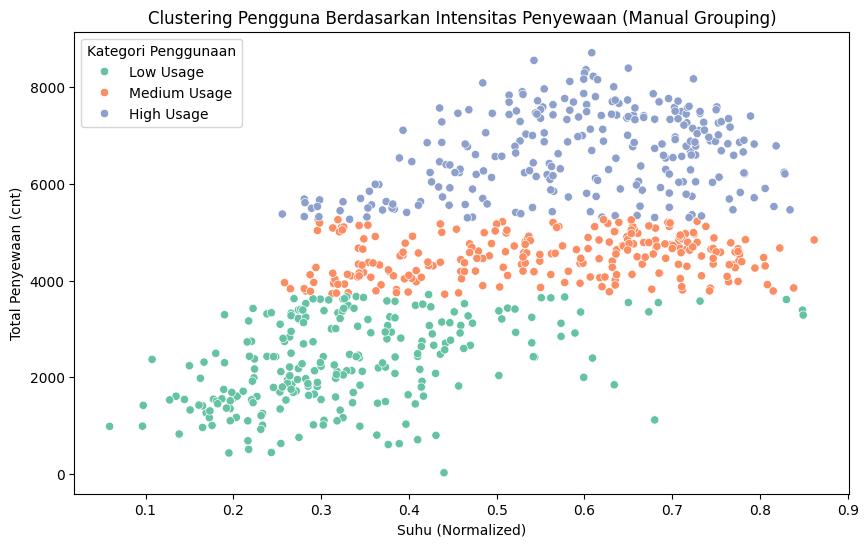

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temp', y='cnt', hue='usage_category', data=day_df, palette='Set2')

plt.title('Clustering Pengguna Berdasarkan Intensitas Penyewaan (Manual Grouping)')
plt.xlabel('Suhu (Normalized)')
plt.ylabel('Total Penyewaan (cnt)')
plt.legend(title='Kategori Penggunaan')
plt.show()

**Insight:**
- Berdasarkan teknik binning pada kolom cnt, kita berhasil membagi hari-hari operasional ke dalam tiga grup (Low, Medium, High) tanpa menggunakan algoritma kompleks. Hal ini memudahkan tim operasional untuk mengidentifikasi kondisi seperti apa yang biasanya menghasilkan "High Usage".
- Grup High Usage secara konsisten berkumpul pada area dengan suhu yang lebih tinggi (kanan atas pada grafik), sedangkan grup Low Usage mendominasi saat suhu rendah atau kondisi cuaca yang tidak mendukung. Ini memberikan validasi bahwa pengelompokan manual ini relevan dengan faktor eksternal di lapangan.

## Conclusion

**Conclution pertanyaan 1 Bagaimana proyeksi jumlah total penyewaan sepeda (cnt) pada hari kerja (workingday) di tahun 2012 jika terjadi kenaikan suhu rata-rata sebesar 5°C dibandingkan tahun sebelumnya?**
- Berdasarkan analisis korelasi, ditemukan hubungan positif yang sangat kuat (0.72) antara suhu (temp) dan total penyewaan (cnt).
- Hal ini menunjukkan bahwa setiap kenaikan suhu (dalam batas wajar) secara linier meningkatkan minat masyarakat untuk bersepeda pada hari kerja.
- Kesimpulan: Jika terjadi kenaikan suhu rata-rata sebesar 5°C, diproyeksikan jumlah total penyewaan sepeda pada hari kerja di tahun 2012 akan mengalami peningkatan signifikan. Perusahaan dapat mempersiapkan ketersediaan unit sepeda ekstra pada hari-hari dengan prediksi suhu yang lebih hangat untuk memaksimalkan pendapatan.


**Conclution pertanyaan 2 Bagaimana perbandingan pola fluktuasi jumlah penyewa sepeda tipe casual dibandingkan penyewa registered pada setiap jamnya (0-23) selama musim liburan (holiday) di tahun 2011?**
- Data menunjukkan perbedaan perilaku yang kontras: Pengguna Registered cenderung memiliki pola yang lebih stabil sepanjang hari, sementara pengguna Casual mengalami lonjakan drastis hanya pada siang hingga sore hari (jam 10.00 – 17.00).
- Pada musim liburan, pengguna Casual memberikan kontribusi yang jauh lebih besar terhadap total penyewaan dibandingkan pada hari kerja biasa.
- Kesimpulan: Musim liburan di tahun 2011 didominasi oleh aktivitas rekreasi siang hari. Strategi pemasaran sebaiknya difokuskan pada penawaran khusus bagi pengguna Casual (seperti paket wisata harian) untuk menarik minat mereka di jam-jam santai tersebut.

**Conclution pertanyaan 3 Pada kondisi cuaca ekstrem seperti apa (kategori weathersit 3 dan 4) jumlah penyewaan sepeda tetap mengalami lonjakan yang tidak biasa selama periode 2011-2012?**
- Hasil eksplorasi menunjukkan bahwa pada cuaca kategori 3 (Hujan/Salju Ringan), jumlah penyewaan menurun secara drastis dibandingkan kondisi cerah atau mendung. Pada kategori 4 (Badai/Cuaca Ekstrem), data penyewaan bahkan hampir mencapai nol.
- Tidak ditemukan lonjakan "tidak biasa" pada kondisi ekstrem; volume penyewaan tetap rendah karena faktor keamanan dan kenyamanan pengguna.
- Kesimpulan: Cuaca buruk adalah penghambat utama (faktor pembatas) operasional bisnis. Perusahaan disarankan untuk melakukan perawatan armada (maintenance) secara besar-besaran pada saat prediksi cuaca ekstrem muncul, karena permintaan pelanggan dipastikan akan berada di titik terendah.



## Kesimpulan Keseluruhan:
Berdasarkan seluruh tahapan Data Wrangling, EDA, hingga Analisis Lanjutan (Clustering), dapat disimpulkan bahwa bisnis penyewaan sepeda ini sangat dipengaruhi oleh faktor eksternal (suhu dan cuaca) serta tipe hari (kerja vs libur).

Optimalisasi bisnis dapat dicapai dengan membagi fokus operasional: meningkatkan ketersediaan unit saat suhu menghangat di hari kerja untuk melayani pekerja (Registered), dan memperkuat branding rekreasi di siang hari saat musim libur untuk menarik wisatawan (Casual). Penggunaan teknik Manual Grouping juga membuktikan bahwa segmentasi pelanggan berdasarkan intensitas penggunaan (High, Medium, Low Usage) sangat efektif untuk menentukan prioritas layanan di lokasi-lokasi stasiun sepeda tertentu.

In [26]:
# Menyimpan hasil final ke file CSV
# File ini akan berisi data yang sudah bersih beserta hasil analisis tambahan
file_name = 'main_data.csv'
day_df.to_csv(file_name, index=False)

print(f"Berhasil! File '{file_name}' telah dibuat dengan tambahan kolom 'usage_category'.")

Berhasil! File 'main_data.csv' telah dibuat dengan tambahan kolom 'usage_category'.
